# Importation

In [82]:
# Import librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [83]:
# Importation des fichiers

df_population = pd.read_csv('population.csv')
df_pop_urbaine = pd.read_csv('population_urbaine.csv',skiprows=4)
df_pib_habitant = pd.read_csv('pib_par_habitant.csv',skiprows=4)
df_croissance_pib = pd.read_csv('Croissance_pib.csv',skiprows=4)
df_dispo_alimentaire = pd.read_csv('Dispo_alimentaire.csv')
df_indice_logistique = pd.read_csv('indice_perf_logistique.csv',skiprows=4)


# Analyse exploratoire

### 1. Analyse exploratoire du fichier df_population

In [84]:
# Dimension du dataframe
df_population.shape
print(f"Nombre de lignes : {df_population.shape[0]}, Nombre de colonnes : {df_population.shape[1]}")

#Type de données
print("\nTypes de données :")
print(df_population.dtypes)

# Valeurs manquantes
print("\nValeurs manquantes :")
print(df_population.isnull().sum())

# Doublons
print("\nDoublons :")
print(df_population.duplicated().sum())


Nombre de lignes : 4411, Nombre de colonnes : 15

Types de données :
Code Domaine               object
Domaine                    object
Code zone                   int64
Zone                       object
Code Élément                int64
Élément                    object
Code Produit                int64
Produit                    object
Code année                  int64
Année                       int64
Unité                      object
Valeur                    float64
Symbole                    object
Description du Symbole     object
Note                       object
dtype: object

Valeurs manquantes :
Code Domaine                 0
Domaine                      0
Code zone                    0
Zone                         0
Code Élément                 0
Élément                      0
Code Produit                 0
Produit                      0
Code année                   0
Année                        0
Unité                        0
Valeur                       0
Symbole      

In [85]:
#Suppression des colonnes inutiles / Renommer les noms de colonnes
df_population = df_population[["Zone", "Année", "Valeur"]]
df_population.rename(columns={"Zone": "Country", "Valeur": "Population"}, inplace=True)
df_population.head()

,Country,Année,Population
0,Afghanistan,2000,"20,779.95"
1,Afghanistan,2001,"21,606.99"
2,Afghanistan,2002,"22,600.77"
3,Afghanistan,2003,"23,680.87"
4,Afghanistan,2004,"24,726.68"


In [86]:
#Filtre sur l'année 2017
df_population = df_population[df_population["Année"] == 2017]
df_population.drop(columns=["Année"], inplace=True)
df_population.head()


,Country,Population
17,Afghanistan,"36,296.11"
36,Afrique du Sud,"57,009.76"
55,Albanie,"2,884.17"
74,Algérie,"41,389.19"
93,Allemagne,"82,658.41"


In [87]:
# Conversion de la population : passage des milliers d'habitants aux habitants réels
df_population["Population"] = df_population["Population"] * 1000

# Vérification
df_population.head()
print(df_population.head())


           Country    Population
17     Afghanistan 36,296,113.00
36  Afrique du Sud 57,009,756.00
55         Albanie  2,884,169.00
74         Algérie 41,389,189.00
93       Allemagne 82,658,409.00


### 2. Analyse exploratoire du fichier df_pop_urbaine

In [88]:
# Dimension du dataframe
df_pop_urbaine.shape
print(f"Nombre de lignes : {df_pop_urbaine.shape[0]}, Nombre de colonnes : {df_pop_urbaine.shape[1]}")

#Type de données
print("\nTypes de données :")
print(df_pop_urbaine.dtypes)

# Valeurs manquantes
print("\nValeurs manquantes :")
print(df_pop_urbaine.isnull().sum())

# Doublons
print("\nDoublons :")
print(df_pop_urbaine.duplicated().sum())

Nombre de lignes : 266, Nombre de colonnes : 70

Types de données :
Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
1960              float64
                   ...   
2021              float64
2022              float64
2023              float64
2024              float64
Unnamed: 69       float64
Length: 70, dtype: object

Valeurs manquantes :
Country Name        2
Country Code        0
Indicator Name      0
Indicator Code      0
1960                4
                 ... 
2021                3
2022                3
2023                3
2024                3
Unnamed: 69       266
Length: 70, dtype: int64

Doublons :
0


In [89]:
#Suppression des colonnes inutiles
df_pop_urbaine = df_pop_urbaine[["Country Name", "Country Code", "2017"]]
df_pop_urbaine.rename(columns={
    "Country Name": "Country",
    "2017": "Urban_Population"
}, inplace=True)

df_pop_urbaine.head()

,Country,Country Code,Urban_Population
0,Aruba,ABW,"47,075.00"
1,NaN,AFE,"226,557,045.00"
2,Afghanistan,AFG,"9,011,456.00"
3,NaN,AFW,"203,221,168.00"
4,Angola,AGO,"19,603,967.00"


In [90]:
#Vérification des valeurs manquantes
df_pop_urbaine[df_pop_urbaine.isna().any(axis=1)]

,Country,Country Code,Urban_Population
1,NaN,AFE,"226,557,045.00"
3,NaN,AFW,"203,221,168.00"
110,Non classifié,INX,NaN
147,Saint-Martin (fr),MAF,NaN
261,Kosovo,XKX,NaN


In [91]:
#Supression des valeurs manquantes
df_pop_urbaine = df_pop_urbaine.dropna(subset=["Country", "Urban_Population"])

# Vérifier le nombre de pays restants
print(f"Nombre de pays restants : {df_pop_urbaine['Country'].nunique()}")

Nombre de pays restants : 261


### 3. Analyse exploratoire du fichier df_pib_habitant

In [92]:
# Dimension du dataframe
df_pib_habitant.shape
print(f"Nombre de lignes : {df_pib_habitant.shape[0]}, Nombre de colonnes : {df_pib_habitant.shape[1]}")

#Type de données
print("\nTypes de données :")
print(df_pib_habitant.dtypes)

# Valeurs manquantes
print("\nValeurs manquantes :")
print(df_pib_habitant.isnull().sum())

# Doublons
print("\nDoublons :")
print(df_pib_habitant.duplicated().sum())

Nombre de lignes : 266, Nombre de colonnes : 70

Types de données :
Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
1960              float64
                   ...   
2021              float64
2022              float64
2023              float64
2024              float64
Unnamed: 69       float64
Length: 70, dtype: object

Valeurs manquantes :
Country Name        2
Country Code        0
Indicator Name      0
Indicator Code      0
1960              115
                 ... 
2021                8
2022                9
2023               17
2024               34
Unnamed: 69       266
Length: 70, dtype: int64

Doublons :
0


In [93]:
#Suppression des colonnes inutiles / Renommer colonnes
df_pib_habitant = df_pib_habitant[["Country Name", "Country Code", "2017"]]

df_pib_habitant.rename(columns={
    "Country Name": "Country",
    "2017": "GDP_per_capita"
}, inplace=True)

In [94]:
# Afficher les lignes avec valeurs manquantes
df_pib_habitant[df_pib_habitant[["Country", "GDP_per_capita"]].isna().any(axis=1)]


,Country,Country Code,GDP_per_capita
1,NaN,AFE,"1,520.21"
3,NaN,AFW,"1,574.23"
69,Érythrée,ERI,NaN
84,Gibraltar,GIB,NaN
110,Non classifié,INX,NaN
147,Saint-Martin (fr),MAF,NaN
193,"Corée, République démocratique de",PRK,NaN
216,Soudan du Sud,SSD,NaN
254,Venezuela,VEN,NaN
255,Îles Vierges britanniques,VGB,NaN


In [95]:
#Suppression des valeurs manquantes
df_pib_habitant = df_pib_habitant.dropna(subset=["Country", "GDP_per_capita"])

print(f"Nombre de pays restants : {df_pib_habitant['Country'].nunique()}")

Nombre de pays restants : 256


### 4. Analyse exploratoire du fichier df_croissance_pib

In [96]:
# Dimension du dataframe
df_croissance_pib.shape
print(f"Nombre de lignes : {df_croissance_pib.shape[0]}, Nombre de colonnes : {df_croissance_pib.shape[1]}")

#Type de données
print("\nTypes de données :")
print(df_croissance_pib.dtypes)

# Valeurs manquantes
print("\nValeurs manquantes :")
print(df_croissance_pib.isnull().sum())

# Doublons
print("\nDoublons :")
print(df_croissance_pib.duplicated().sum())

Nombre de lignes : 266, Nombre de colonnes : 70

Types de données :
Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
1960              float64
                   ...   
2021              float64
2022              float64
2023              float64
2024              float64
Unnamed: 69       float64
Length: 70, dtype: object

Valeurs manquantes :
Country Name        2
Country Code        0
Indicator Name      0
Indicator Code      0
1960              266
                 ... 
2021                9
2022               10
2023               17
2024               34
Unnamed: 69       266
Length: 70, dtype: int64

Doublons :
0


In [97]:
#Suppression des colonnes inutiles / Renommer les colonnes
df_croissance_pib = df_croissance_pib[["Country Name", "Country Code", "2017"]]

df_croissance_pib.rename(columns={
    "Country Name": "Country",
    "2017": "GDP_growth"
}, inplace=True)

In [98]:
# Afficher les valeurs manquantes
df_croissance_pib[df_croissance_pib[["Country", "GDP_growth"]].isna().any(axis=1)]

,Country,Country Code,GDP_growth
1,NaN,AFE,2.70
3,NaN,AFW,2.30
69,Érythrée,ERI,NaN
84,Gibraltar,GIB,NaN
110,Non classifié,INX,NaN
137,Liechtenstein,LIE,NaN
172,Nouvelle-Calédonie,NCL,NaN
193,"Corée, République démocratique de",PRK,NaN
216,Soudan du Sud,SSD,NaN
254,Venezuela,VEN,NaN


In [99]:
#Suppression des valeurs manquantes
df_croissance_pib = df_croissance_pib.dropna(subset=["Country", "GDP_growth"])

print(f"Pays restants : {df_croissance_pib['Country'].nunique()}")

Pays restants : 255


### 5. Analyse exploratoire du fichier df_dispo_alimentaire

In [100]:
# Dimension du dataframe
df_dispo_alimentaire.shape
print(f"Nombre de lignes : {df_dispo_alimentaire.shape[0]}, Nombre de colonnes : {df_dispo_alimentaire.shape[1]}")

#Type de données
print("\nTypes de données :")
print(df_dispo_alimentaire.dtypes)

# Valeurs manquantes
print("\nValeurs manquantes :")
print(df_dispo_alimentaire.isnull().sum())

# Doublons
print("\nDoublons :")
print(df_dispo_alimentaire.duplicated().sum())

Nombre de lignes : 176600, Nombre de colonnes : 14

Types de données :
Code Domaine               object
Domaine                    object
Code zone                   int64
Zone                       object
Code Élément                int64
Élément                    object
Code Produit                int64
Produit                    object
Code année                  int64
Année                       int64
Unité                      object
Valeur                    float64
Symbole                    object
Description du Symbole     object
dtype: object

Valeurs manquantes :
Code Domaine              0
Domaine                   0
Code zone                 0
Zone                      0
Code Élément              0
Élément                   0
Code Produit              0
Produit                   0
Code année                0
Année                     0
Unité                     0
Valeur                    0
Symbole                   0
Description du Symbole    0
dtype: int64

Doublons :


In [101]:
#Suppression des colonnes inutiles
df_dispo_alimentaire = df_dispo_alimentaire[["Zone", "Année", "Produit", "Élément", "Valeur"]]

df_dispo_alimentaire.head()

,Zone,Année,Produit,Élément,Valeur
0,Afghanistan,2017,Blé et produits,Production,"4,281.00"
1,Afghanistan,2017,Blé et produits,Importations - Quantité,"2,302.00"
2,Afghanistan,2017,Blé et produits,Variation de stock,-119.00
3,Afghanistan,2017,Blé et produits,Exportations - Quantité,0.00
4,Afghanistan,2017,Blé et produits,Disponibilité intérieure,"6,701.00"


In [102]:
# 1. Garder seulement les colonnes utiles
df_dispo_alimentaire = df_dispo_alimentaire[["Zone", "Année", "Produit", "Élément", "Valeur"]]

# 2. Filtrer l'année 2017
df_dispo_alimentaire = df_dispo_alimentaire[df_dispo_alimentaire["Année"] == 2017]

# 3. Filtrer le produit "Viande de volaille"
df_dispo_alimentaire = df_dispo_alimentaire[df_dispo_alimentaire["Produit"] == "Viande de Volailles"]

# 4. Garder seulement les éléments utiles
elements_utiles = [
    "Production",
    "Importations - Quantité",
    "Exportations - Quantité",
    "Disponibilité alimentaire en quantité (kg/personne/an)"
]
df_dispo_alimentaire = df_dispo_alimentaire[df_dispo_alimentaire["Élément"].isin(elements_utiles)]

# 5. Transformer en format large (1 ligne = 1 pays, 1 colonne = chaque élément)
df_dispo_alimentaire = df_dispo_alimentaire.pivot(
    index="Zone",
    columns="Élément",
    values="Valeur"
).reset_index()

# 6. Renommer les colonnes
df_dispo_alimentaire.rename(columns={
    "Zone": "Country",
    "Importations - Quantité": "Importations",
    "Exportations - Quantité": "Exportations",
    "Disponibilité alimentaire en quantité (kg/personne/an)": "Disponibilite_kg_hab"
}, inplace=True)

# 7. Vérification
df_dispo_alimentaire.head()


Élément,Country,Disponibilite_kg_hab,Exportations,Importations,Production
0,Afghanistan,1.53,NaN,29.00,28.00
1,Afrique du Sud,35.69,63.00,514.00,"1,667.00"
2,Albanie,16.36,0.00,38.00,13.00
3,Algérie,6.38,0.00,2.00,275.00
4,Allemagne,19.47,646.00,842.00,"1,514.00"


In [103]:
#Afficher les valeurs manquantes
df_dispo_alimentaire[df_dispo_alimentaire.isna().any(axis=1)]

Élément,Country,Disponibilite_kg_hab,Exportations,Importations,Production
0,Afghanistan,1.53,NaN,29.00,28.00
13,Bahamas,43.17,NaN,24.00,6.00
14,Bangladesh,1.50,NaN,0.00,249.00
23,Burkina Faso,2.27,NaN,0.00,46.00
26,Cabo Verde,17.62,NaN,12.00,1.00
27,Cambodge,2.34,NaN,10.00,28.00
40,Cuba,23.72,NaN,312.00,29.00
43,Djibouti,2.68,NaN,3.00,NaN
54,Gambie,3.53,NaN,16.00,2.00
56,Grenade,45.70,NaN,7.00,1.00


In [104]:
# Remplacer NaN par 0 pour Production, Importations et Exportations
df_dispo_alimentaire["Production"] = df_dispo_alimentaire["Production"].fillna(0)
df_dispo_alimentaire["Importations"] = df_dispo_alimentaire["Importations"].fillna(0)
df_dispo_alimentaire["Exportations"] = df_dispo_alimentaire["Exportations"].fillna(0)

# Supprimer les cas incohérents :
# consommation > 0 mais aucune production et aucune importation
mask_incoh = (
    (df_dispo_alimentaire["Disponibilite_kg_hab"] > 0) &
    (df_dispo_alimentaire["Production"] == 0) &
    (df_dispo_alimentaire["Importations"] == 0)
)
df_dispo_alimentaire = df_dispo_alimentaire[~mask_incoh]

# Contrôle final
print(df_dispo_alimentaire.isna().sum())
print(f"Pays restants : {df_dispo_alimentaire['Country'].nunique()}")
df_dispo_alimentaire.head()


Élément
Country                 0
Disponibilite_kg_hab    0
Exportations            0
Importations            0
Production              0
dtype: int64
Pays restants : 170


Élément,Country,Disponibilite_kg_hab,Exportations,Importations,Production
0,Afghanistan,1.53,0.00,29.00,28.00
1,Afrique du Sud,35.69,63.00,514.00,"1,667.00"
2,Albanie,16.36,0.00,38.00,13.00
3,Algérie,6.38,0.00,2.00,275.00
4,Allemagne,19.47,646.00,842.00,"1,514.00"


### 6. Analyse exploratoire du fichier df_indice_logistique

In [105]:
# Dimension du dataframe
df_indice_logistique.shape
print(f"Nombre de lignes : {df_indice_logistique.shape[0]}, Nombre de colonnes : {df_indice_logistique.shape[1]}")

#Type de données
print("\nTypes de données :")
print(df_indice_logistique.dtypes)

# Valeurs manquantes
print("\nValeurs manquantes :")
print(df_indice_logistique.isnull().sum())

# Doublons
print("\nDoublons :")
print(df_indice_logistique.duplicated().sum())

Nombre de lignes : 266, Nombre de colonnes : 70

Types de données :
Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
1960              float64
                   ...   
2021              float64
2022              float64
2023              float64
2024              float64
Unnamed: 69       float64
Length: 70, dtype: object

Valeurs manquantes :
Country Name        2
Country Code        0
Indicator Name      0
Indicator Code      0
1960              266
                 ... 
2021              266
2022               80
2023              266
2024              266
Unnamed: 69       266
Length: 70, dtype: int64

Doublons :
0


In [106]:
# Vérifier si il y a des données pour l'année 2017
print("2017 in columns ?", "2017" in df_indice_logistique.columns)

# Si oui, afficher quelques valeurs
if "2017" in df_indice_logistique.columns:
    print(df_indice_logistique[["Country Name","Country Code","2017"]].dropna().head(10))
    print("Nombre de pays avec LPI en 2017 :", df_indice_logistique["2017"].notna().sum())


2017 in columns ? True
Empty DataFrame
Columns: [Country Name, Country Code, 2017]
Index: []
Nombre de pays avec LPI en 2017 : 0


In [107]:
# Suppression des colonnes inutiles / Indice logistique non disponible pour 2017, on garde l'année 2018
df_indice_logistique = df_indice_logistique[["Country Name","Country Code","2018"]].copy()

# Renommer colonne
df_indice_logistique.rename(columns={
    "Country Name":"Country",
    "2018":"LPI_2018"
}, inplace=True)

df_indice_logistique.head()

,Country,Country Code,LPI_2018
0,Aruba,ABW,NaN
1,NaN,AFE,2.49
2,Afghanistan,AFG,1.95
3,NaN,AFW,2.41
4,Angola,AGO,2.05


In [108]:
# Afficher les valeurs manquantes
df_indice_logistique[df_indice_logistique.isna().any(axis=1)]


,Country,Country Code,LPI_2018
0,Aruba,ABW,NaN
1,NaN,AFE,2.49
3,NaN,AFW,2.41
6,Andorre,AND,NaN
11,Samoa américaines,ASM,NaN
...,...,...,...
255,Îles Vierges britanniques,VGB,NaN
256,Îles Vierges (EU),VIR,NaN
258,Vanuatu,VUT,NaN
260,Samoa,WSM,NaN


In [109]:
# Suppression lignes où Country est NaN (agrégats) ou LPI_2018 est NaN (pas de donnée publiée)
df_indice_logistique = df_indice_logistique.dropna(subset=["Country", "LPI_2018"])

# Contrôle
print(f"Pays restants : {df_indice_logistique['Country'].nunique()}")
df_indice_logistique.head()


Pays restants : 205


,Country,Country Code,LPI_2018
2,Afghanistan,AFG,1.95
4,Angola,AGO,2.05
5,Albanie,ALB,2.66
7,Le monde arabe,ARB,2.68
8,Émirats arabes unis,ARE,3.96


In [110]:
# Arrondissement de l'indice logistique à deux décimales après la virgule
df_indice_logistique["LPI_2018"] = df_indice_logistique["LPI_2018"].round(2)

# Vérification
df_indice_logistique.head()


,Country,Country Code,LPI_2018
2,Afghanistan,AFG,1.95
4,Angola,AGO,2.05
5,Albanie,ALB,2.66
7,Le monde arabe,ARB,2.68
8,Émirats arabes unis,ARE,3.96


### Suppression des agrégats régionaux pour ne conserver que les pays

In [111]:
# Charger le metadata pays
df_meta = pd.read_csv("Metadata_Country_API_SP.URB.TOTL_DS2_fr_csv_v2_783563.csv")

# Aperçu des colonnes
df_meta.head()

,Country Name,Country Code,Region,Income_Group,Unnamed: 4
0,Aruba,ABW,NaN,Revenu élevé,NaN
1,NaN,AFE,NaN,Agrégats,NaN
2,Afghanistan,AFG,Afrique du Nord et Moyen-Orient (hors revenu é...,Faible revenu,NaN
3,NaN,AFW,NaN,Agrégats,NaN
4,Angola,AGO,Afrique subsaharienne (hors revenu élevé),"Revenu intermédiaire, tranche inférieure",NaN


In [112]:
# Créer une liste des codes d'agrégats
agg_codes = set(df_meta.loc[df_meta["Income_Group"] == "Agrégats", "Country Code"])

# Vérification
print("Nombre d'agrégats :", len(agg_codes))
print("Exemples :", list(agg_codes)[:10])

Nombre d'agrégats : 49
Exemples : ['TEC', 'IDA', 'HIC', 'CSS', 'LDC', 'LMC', 'IBD', 'LTE', 'PSS', 'SSA']


In [113]:
# Suppression des agrégats dans tous les fichiers Banque mondiale
df_pib_habitant = df_pib_habitant[~df_pib_habitant["Country Code"].isin(agg_codes)]
df_croissance_pib = df_croissance_pib[~df_croissance_pib["Country Code"].isin(agg_codes)]
df_pop_urbaine = df_pop_urbaine[~df_pop_urbaine["Country Code"].isin(agg_codes)]
df_indice_logistique = df_indice_logistique[~df_indice_logistique["Country Code"].isin(agg_codes)]

print("PIB/hab :", df_pib_habitant["Country"].nunique())
print("Croissance PIB :", df_croissance_pib["Country"].nunique())
print("Pop urbaine :", df_pop_urbaine["Country"].nunique())
print("Indice logistique :", df_indice_logistique["Country"].nunique())

PIB/hab : 210
Croissance PIB : 209
Pop urbaine : 215
Indice logistique : 159


## Jointures

In [114]:
# population
df_final = df_population.copy()

# Ajoute la population urbaine
df_final = df_final.merge(df_pop_urbaine[["Country", "Urban_Population"]],
                          on="Country", how="inner")

# Ajoute le PIB/habitant
df_final = df_final.merge(df_pib_habitant[["Country", "GDP_per_capita"]],
                          on="Country", how="inner")

# Ajoute la croissance du PIB
df_final = df_final.merge(df_croissance_pib[["Country", "GDP_growth"]],
                          on="Country", how="inner")

# Ajoute la dispo alimentaire
df_final = df_final.merge(df_dispo_alimentaire,
                          on="Country", how="inner")

# Ajoute l’indice logistique
df_final = df_final.merge(df_indice_logistique[["Country", "LPI_2018"]],
                          on="Country", how="inner")

print("Nombre de pays communs :", df_final["Country"].nunique())
df_final.head()

Nombre de pays communs : 128


,Country,Population,Urban_Population,GDP_per_capita,GDP_growth,Disponibilite_kg_hab,Exportations,Importations,Production,LPI_2018
0,Afghanistan,"36,296,113.00","9,011,456.00",525.47,2.65,1.53,0.00,29.00,28.00,1.95
1,Afrique du Sud,"57,009,756.00","37,952,754.00","6,618.34",1.16,35.69,63.00,514.00,"1,667.00",3.38
2,Albanie,"2,884,169.00","1,706,345.00","4,614.05",3.28,16.36,0.00,38.00,13.00,2.66
3,Algérie,"41,389,189.00","30,037,974.00","4,554.67",1.50,6.38,0.00,2.00,275.00,2.45
4,Allemagne,"82,658,409.00","63,861,626.00","45,526.60",2.72,19.47,646.00,842.00,"1,514.00",4.20


In [115]:
# Conversion en tonnes
df_final["Production"]   = df_final["Production"] * 1000
df_final["Importations"] = df_final["Importations"] * 1000
df_final["Exportations"] = df_final["Exportations"] * 1000

# Renommer les colonnes avec unités
df_final.rename(columns={
    "Production": "Production (t)",
    "Importations": "Importations (t)",
    "Exportations": "Exportations (t)",
    "Urban_Population": "Population urbaine",
    "GDP_per_capita": "PIB par habitant (USD)",
    "GDP_growth": "Croissance PIB (%)",
    "Disponibilite_kg_hab": "Disponibilité volaille (kg/hab/an)",
    "LPI_2018": "Indice logistique (0-5)"
}, inplace=True)

df_final.head()

,Country,Population,Population urbaine,PIB par habitant (USD),Croissance PIB (%),Disponibilité volaille (kg/hab/an),Exportations (t),Importations (t),Production (t),Indice logistique (0-5)
0,Afghanistan,"36,296,113.00","9,011,456.00",525.47,2.65,1.53,0.00,"29,000.00","28,000.00",1.95
1,Afrique du Sud,"57,009,756.00","37,952,754.00","6,618.34",1.16,35.69,"63,000.00","514,000.00","1,667,000.00",3.38
2,Albanie,"2,884,169.00","1,706,345.00","4,614.05",3.28,16.36,0.00,"38,000.00","13,000.00",2.66
3,Algérie,"41,389,189.00","30,037,974.00","4,554.67",1.50,6.38,0.00,"2,000.00","275,000.00",2.45
4,Allemagne,"82,658,409.00","63,861,626.00","45,526.60",2.72,19.47,"646,000.00","842,000.00","1,514,000.00",4.20


## Feature engineering : Création de 3 nouvelles variables

In [116]:
# Disponibilité totale volaille (t) – utile pour calculer l'autosuffisance
df_final["Disponibilite totale (t)"] = (
    df_final["Disponibilité volaille (kg/hab/an)"] * df_final["Population"] / 1000
)

# Dépendance import (%) – on la calcule mais on la supprimera (doublon avec autosuffisance)
df_final["Dependance import (%)"] = (
    df_final["Importations (t)"] / (df_final["Production (t)"] + df_final["Importations (t)"]) * 100
)

# Taux d’urbanisation (%)
df_final["Taux urbanisation (%)"] = (
    df_final["Population urbaine"] / df_final["Population"] * 100
)

# Taux d’autosuffisance (%) – variable clé
df_final["Taux autosuffisance (%)"] = (
    df_final["Production (t)"] / df_final["Disponibilite totale (t)"] * 100
)

# --- Nettoyage des redondances (on garde 8 variables pertinentes) ---
# - Population urbaine  -> doublon avec Taux urbanisation
# - Importations (t)    -> doublon avec Dependance import (qu'on retire aussi)
# - Production (t)      -> incluse dans Taux_autosuffisance
# - Disponibilite totale (t) -> utilisée pour le ratio puis retirée
# - Dependance import (%) -> inverse de l'autosuffisance
df_final.drop(
    columns=[
        "Population urbaine",
        "Importations (t)",
        "Production (t)",
        "Disponibilite totale (t)",
        "Dependance import (%)",
    ],
    inplace=True
)

# Aarrondir les pourcentages
cols_pct = ["Croissance PIB (%)", "Taux urbanisation (%)", "Taux autosuffisance (%)"]
df_final[cols_pct] = df_final[cols_pct].round(2)

print(df_final.shape)
df_final.head()


(128, 9)


,Country,Population,PIB par habitant (USD),Croissance PIB (%),Disponibilité volaille (kg/hab/an),Exportations (t),Indice logistique (0-5),Taux urbanisation (%),Taux autosuffisance (%)
0,Afghanistan,"36,296,113.00",525.47,2.65,1.53,0.00,1.95,24.83,50.42
1,Afrique du Sud,"57,009,756.00","6,618.34",1.16,35.69,"63,000.00",3.38,66.57,81.93
2,Albanie,"2,884,169.00","4,614.05",3.28,16.36,0.00,2.66,59.16,27.55
3,Algérie,"41,389,189.00","4,554.67",1.50,6.38,0.00,2.45,72.57,104.14
4,Allemagne,"82,658,409.00","45,526.60",2.72,19.47,"646,000.00",4.20,77.26,94.07


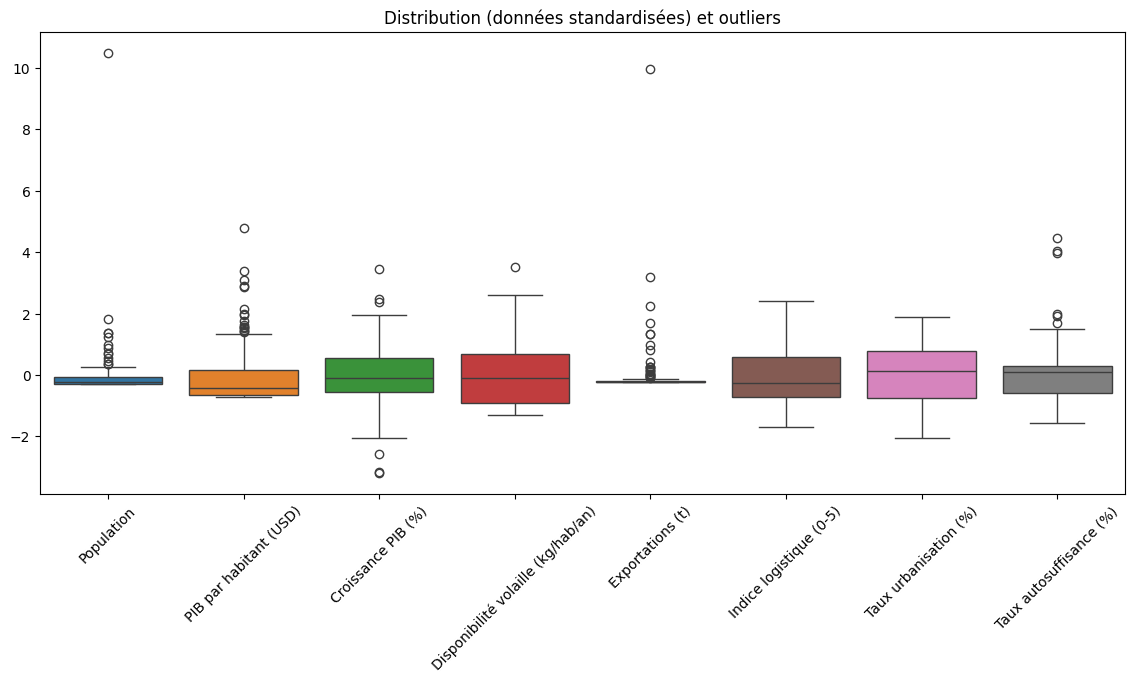

Variable 'Population' – outliers (|z|>3) : Inde
Variable 'PIB par habitant (USD)' – outliers (|z|>3) : Luxembourg, Norvège, Suisse
Variable 'Croissance PIB (%)' – outliers (|z|>3) : Koweït, Malte, Trinité-et-Tobago
Variable 'Disponibilité volaille (kg/hab/an)' – outliers (|z|>3) : Israël
Variable 'Exportations (t)' – outliers (|z|>3) : Brésil, Pays-Bas
Variable 'Taux autosuffisance (%)' – outliers (|z|>3) : Belgique, Pays-Bas, Pérou


In [117]:
# Vérification des outliers

# Standardiser les colonnes numériques avant boxplot
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final.select_dtypes(include=[float,int]))

# Transformer en DataFrame pour garder les noms de colonnes
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=df_final.select_dtypes(include=[float,int]).columns,
    index=df_final["Country"]  # on met le pays en index pour lister les outliers
)

# Boxplot des données standardisées
plt.figure(figsize=(14,6))
sns.boxplot(data=X_scaled_df)
plt.xticks(rotation=45)
plt.title("Distribution (données standardisées) et outliers")
plt.show()

# --- Lister les pays outliers pour chaque variable ---
seuil = 3  # seuil en écart-type
outliers_dict = {}

for var in X_scaled_df.columns:
    outliers = X_scaled_df.index[(X_scaled_df[var] > seuil) | (X_scaled_df[var] < -seuil)].tolist()
    if outliers:
        outliers_dict[var] = outliers

# Affichage clair
for var, pays in outliers_dict.items():
    print(f"Variable '{var}' – outliers (|z|>{seuil}) : {', '.join(pays)}")



**Interprétation des outliers**

* Population (Inde)
L’Inde apparaît logiquement comme un outlier car elle a une population extrêmement élevée par rapport à la majorité des autres pays de l’échantillon. C’est un cas particulier qui peut fortement influencer les analyses si on ne standardise pas.

* PIB par habitant (Luxembourg, Norvège, Suisse)
Ces pays sont connus pour être parmi les plus riches du monde. Leur PIB/habitant est très supérieur à la moyenne mondiale, ce qui en fait des outliers naturels sur cette variable.

* Croissance du PIB (%) (Koweït, Malte, Trinité-et-Tobago)
Ces pays présentent des taux de croissance économique atypiques (souvent liés à des effets ponctuels comme l’exploitation des ressources pétrolières ou des spécificités fiscales), ce qui les rend extrêmes sur cette dimension.

* Disponibilité volaille (kg/hab/an) (Israël)
Israël a une consommation de volaille par habitant particulièrement élevée par rapport aux autres pays. C’est un indicateur fort d’une habitude alimentaire spécifique.

* Exportations (t) (Brésil, Pays-Bas)
Le Brésil est un des plus grands exportateurs mondiaux de volaille, et les Pays-Bas sont un hub logistique majeur en Europe. Ces deux pays sortent donc très largement de la norme sur cette variable.

* Taux d’autosuffisance (%) (Belgique, Pays-Bas, Pérou)
Ces pays ont un taux d’autosuffisance inhabituellement élevé par rapport à leur consommation intérieure. Cela traduit une production très supérieure à leurs besoins internes (Pays-Bas et Belgique exportent énormément de produits agroalimentaires, Pérou est très producteur par rapport à sa population).

In [119]:
# Création du fichier CSV
df_final.to_csv("df_final_clean.csv", index=False)

from google.colab import files
files.download("df_final_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>